# Домашнее задание 10: Visual Language Models

Это домашнее задание направлено на изучение бимодальных моделей, интегрирующих визуальные и текстовые данные. В рамках данного задания мы поработаем с подвыборкой датасета COCO, где применим рассмотренные на лекциях модели для того чтобы найти bounding box'ы объектов на изображениях, а также семантические и инстанс сегментационные маски для них.

### План работы

1. **Подготовка датасета:** Создание класса для работы с данными.
2. **Генерация описаний с помощью BLIP:** Создание текстовых описаний изображений с использованием BLIP.
3. **Генерация тегов с помощью Recognize Anything Model (RAM):** Создание релевантных тегов для изображений.
4. **Определение bbox'ов с помощью Grounding DINO:** Использование сгенерированных описаний и тегов для детекции объектов через Grounding DINO.
5. **Автоматическая фильтрация несоответствий:** Реализация метода для автоматической фильтрации галлюционаций и ложных срабатываний с помощью CLIP.
6. **Сегментация с помощью Segment Anything Model (SAM):** Использование полученных в 4 задании bounding box'ов для создания сегментационных масок с помощью SAM.

In [1]:
# Устанавливаем нужные библиотеки
#!pip install git+https://github.com/facebookresearch/segment-anything.git
#!pip install git+https://github.com/xinyu1205/recognize-anything.git
#!pip install git+https://github.com/IDEA-Research/GroundingDINO.git
#!pip install fairscale

In [2]:
# Импортируем библиотеки
import os
import json
import inspect
import csv
import ast
from collections import defaultdict
from typing import Any, Optional

import cv2
import torch
import transformers
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from PIL import Image
from tqdm import tqdm
from albumentations.pytorch import ToTensorV2
from ram.models import ram_plus
from ram import inference_ram

import groundingdino
import groundingdino.datasets.transforms as T
from groundingdino.util.inference import load_model, predict
from segment_anything import SamPredictor, sam_model_registry

c:\Users\asang\miniconda3\envs\face_swap\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.23). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\asang\miniconda3\envs\face_swap\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\asang\miniconda3\envs\face_swap\lib\site-packages\timm\models\hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\asang\miniconda3\envs\face_swap\lib\site-packages\timm\models\registry.py:4: Futu

### Задание 1: Подготовка датасета

Реализуйте класс для работы с датасетом в формате COCO (Common Objects in Context):

1. Создайте класс `COCODataset` со следующими параметрами инициализации:
   - `image_dir` (str): путь к директории с изображениями
   - `category_mapping_file` (str): путь к файлу с маппингом категорий (JSON)
   - `annotation_file` (str): путь к файлу аннотаций в формате COCO (JSON), если есть

2. Класс должен реализовывать следующие методы:
   - `__len__` -> int: возвращает количество изображений в датасете
   
   - `__getitem__(idx: int) -> tuple[np.ndarray, dict]`: возвращает пару (изображение, аннотации)
     - изображение: numpy array размера (H, W, 3) в формате RGB
     - аннотации: словарь, содержащий:
       - 'image_id': int - ID изображения
       - 'boxes': np.ndarray с координатами bbox'ов в формате [x, y, width, height]
       - 'masks': np.ndarray бинарных масок
       - 'labels': list[str] с названиями лейблов
       - 'captions': list[str] с описаниями (может быть пустым)
   
   - `make_visualization(image: np.ndarray, annotations: dict) -> np.ndarray`:
     возвращает изображение с отрисованными:
     - bbox'ами с подписями лейблов
     - сегментационными масками

**Подсказки:**
- Используйте cv2 для работы с изображениями
- Если аннотаций нет, то используйте os.listdir(image_dir) для получения списка изображений и привяжите id к названию файла
- Остальные поля в возвращаемом словаре аннотаций должны быть пустыми
- Используйте детерминированные цвета на основе индекса объекта - [(i * 50) % 255, ((i * 50 + 85) % 255), ((i * 50 + 170) % 255)] (RGB)
- Для отрисовки текста используйте cv2.putText с белым цветом (255, 255, 255)

In [6]:
class COCODataset:
    def __init__(self, image_dir: str, category_mapping_file: str, annotation_file: Optional[str] = None):
        self.image_dir = image_dir
        self.category_mapping_file = category_mapping_file
        self.annotation_file = annotation_file
        
        # Load annotations
        self.annotations = None
        if annotation_file is not None:
            with open(annotation_file, 'r') as f:
                self.annotations = json.load(f)
            ...
        else:
            self.images_list = os.listdir(image_dir)

        # Load category mapping
        with open(category_mapping_file, 'r') as f:
            self.category_mapping = json.load(f)
            
        ...
        
    def __len__(self) -> int:
        return len(self.annotations['images'])
    
    def __getitem__(self, idx: int) -> tuple[np.ndarray, dict]:
        if self.annotations is not None:
            img_info = self.annotations['images'][idx]
            img_id = img_info['id']
        else:
            img_info = {'file_name': self.images_list[idx]}
            img_id = self.images_list[idx]
            
        image = ...
        boxes, masks, captions, labels = [], [], [], []
        
        ...

        annotations = {
            'image_id': img_id,
            'boxes': np.array(boxes),
            'masks': np.array(masks),
            'captions': captions,
            'labels': labels
            }
        
        return image, annotations
    
    def _polygon_to_mask(self, polygons: list[list[float]], height: int, width: int) -> np.ndarray:
        """
        Конвертирует полигоны в бинарную маску
        """
        mask = np.zeros((height, width), dtype=np.uint8)
        for polygon in polygons:
            polygon = np.array(polygon).reshape(-1, 2)
            polygon = polygon.astype(np.int32)
            cv2.fillPoly(mask, [polygon], 1)
        return mask
    
    def make_visualization(self, image: np.ndarray, annotations: dict) -> np.ndarray:
        vis_image = image.copy()
        
        # Draw segmentation masks
        if len(annotations['masks']) > 0:
            mask_overlay = np.zeros_like(image)
            ...
            vis_image = cv2.addWeighted(vis_image, 0.7, mask_overlay, 0.3, 0)
        
        # Draw bounding boxes and labels
        ...
        
        return vis_image

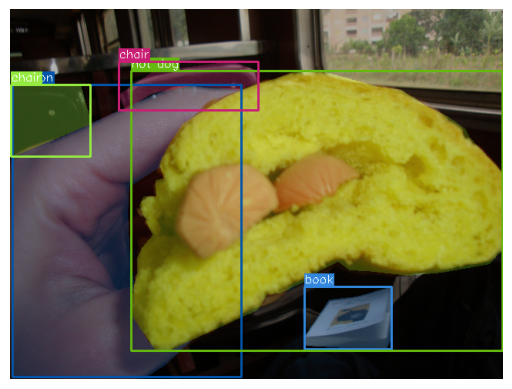

In [8]:
src_dir = os.getcwd()
image_dir = os.path.join(src_dir, 'data', 'student')
test_dir = os.path.join(src_dir, 'data', 'test')
annotation_file = os.path.join(src_dir, 'data', 'annotations', 'student_annotations.json')
category_mapping_file = os.path.join(src_dir, 'data', 'annotations', 'coco_categories.json')

dataset = COCODataset(image_dir, category_mapping_file, annotation_file)
sample, annotations = dataset[0]
sample_vis = dataset.make_visualization(sample, annotations)

plt.imshow(sample_vis)
plt.axis('off')
plt.show()

### Задание 2: Генерация описаний с помощью BLIP


В данном задании необходимо реализовать класс `BlipProcessor`, который будет использовать модель BLIP ("Salesforce/blip-image-captioning-base") из библиотеки transformers для генерации текстовых описаний изображений.

Создайте класс `BlipProcessor` со следующей функциональностью:
   - Инициализация модели BLIP и его препроцессинга для генерации описаний изображений
   - Метод `process_image`, который принимает:
     - изображение
     - id изобаржения
   - Реализация механизма кэширования результатов на основе image_id

**Ожидаемый результат**:
- Класс должен корректно генерировать текстовые описания для входных изображений
- При повторной обработке одного и того же изображения (с тем же image_id) результат должен браться из кэша
- Описания должны генерироваться на английском языке

In [6]:
class BlipProcessor:
    def __init__(self, device: str = "cpu"):
        pass
        
    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> str:
        pass

In [8]:
blip_processor = BlipProcessor("cpu")
image, annotations = dataset[0]
caption = blip_processor.process_image(image, annotations['image_id'])
print(caption)

a person holding a piece of food in their hand


In [9]:
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_captions = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    caption = blip_processor.process_image(image)
    test_captions.append((annotations['image_id'], caption))

with open('test_captions.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'caption'])
    writer.writerows(test_captions)

5it [00:04,  1.02it/s]


В качестве ответа загрузите полученный csv в LMS.

### Задание 3: Генерация тегов с помощью Recognize Anything Model (RAM)


Вам необходимо реализовать класс `RamProcessor`, который будет использовать модель Recognize Anything Model++ (RAM++) для генерации тегов изображений. Скачайте веса с [ссылки](https://huggingface.co/xinyu1205/recognize-anything-plus-model/blob/main/ram_plus_swin_large_14m.pth) в [официальном репозитории](https://github.com/xinyu1205/recognize-anything/) и поместите в папку 'pretrained'.

1. Создайте класс `RamProcessor`, который должен:
   - Инициализировать модель RAM++, а также препроцессинг к нему (`image_size` берите 384)
   - Иметь метод `process_image`, который принимает изображение и опционально идентификатор изображения (image_id)
   - Возвращать список тегов, сгенерированных для изображения

2. Реализуйте механизм кэширования:
   - Если при вызове метода `process_image` был предоставлен идентификатор изображения (image_id), класс должен сохранить сгенерированные теги в кэше
   - При повторном запросе с тем же идентификатором изображения теги должны браться из кэша без повторной обработки изображения

In [6]:
class RamProcessor:
    def __init__(self, categories: list[str], device: str = "cpu"):
        pass

    def process_image(self, image: np.ndarray, image_id: Optional[int] = None) -> list[str]:
        pass

In [12]:
categories = list(dataset.category_mapping.values())

ram_processor = RamProcessor(categories, "cpu")
image, annotations = dataset[0]
tags = ram_processor.process_image(image, annotations['image_id'])
print(tags)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


--------------
pretrained/ram_plus_swin_large_14m.pth
--------------
load checkpoint from pretrained/ram_plus_swin_large_14m.pth
vit: swin_l
biscuit | bite | bread | car | catch | hand | food | person | muffin | pastry


In [13]:
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_tags = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    tags = ram_processor.process_image(image)
    test_tags.append((annotations['image_id'], tags))

with open('test_tags.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'tags'])
    writer.writerows(test_tags)

5it [00:04,  1.13it/s]


Загрузите полученный csv в LMS.

### Задание 4: Определение bbox'ов с помощью Grounding DINO

Реализуем класс `DinoProcessor`, который будет использовать Grounding DINO для детекции объектов на основе текстового промпта (caption/tags). Скачайте [веса](https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swinb_cogcoor.pth) с [официального репозитория](https://github.com/IDEA-Research/GroundingDINO) и поместите и в папку 'pretrained'.

С Grounding DINO вы уже поработали на практике, сейчас лишь требуется воспроизвести тоже самое в виде класса, метод `process_image` должен возвращать bbox'ы (в формате x, y, w, h, где x и y - координаты левого верхнего угла), логиты и классы. Не забудьте имплементировать кэширование как в предыдущих заданиях.

**Подсказка**: `load_image` принимает путь к файлу, метод `process_image` работает с `np.ndarray`.

**Подсказка 2**: сами решите какой текстовый промпт лучше подавать в модель - caption от BLIP или теги от RAM - а также *как* его лучше подавать в модель. Посмотрите еще раз практику, если потребуется.

In [14]:
class DinoProcessor:
    def __init__(self, device: str = 'cpu'):
        pass

    def process_image(self, image: np.ndarray, text_prompt: str, image_id: int = None) -> tuple[torch.Tensor, torch.Tensor, list[str]]:
       pass

In [ ]:
ram_processor = RamProcessor("cpu")
sample, annotations = dataset[1]
tags = ram_processor.process_image(sample)
tags = " . ".join(tags.split(' | ')) + " . "

dino_processor = DinoProcessor("cpu")
bboxes, logits, labels = dino_processor.process_image(sample, tags)
annotations_pred = {
                   'image_id': annotations['image_id'],
                   'boxes': bboxes.detach().cpu().tolist(),
                   'labels': labels,
                   'masks': [],
                   'captions': []
                   }
sample_vis = dataset.make_visualization(sample, annotations_pred)

plt.imshow(sample_vis)
plt.axis('off')
plt.show()

По аналогии с предыдущими заданиями прогоните DinoProcessor на тестовых данных, сохраните в csv - оно должно иметь три колонки image_id, bbox, label (каждая детекция на новой строке).

### Задание 5: Фильтрация результатов с помощью CLIP

В данном задании вам необходимо реализовать класс `ClipProcessor`, который будет использовать модель CLIP из библиотеки transformers для фильтрации аннотаций изображений.

1. Реализуйте класс `ClipProcessor`, который должен инициализировать модель CLIP (используйте "openai/clip-vit-base-patch32") из библиотеки transformers.

2. Реализуйте метод `process_image`, который должен принимать изображение и словарь аннотаций, а возвращать отфильтрованный словарь аннотаций.

3. Метод `process_image` должен выполнять следующие задачи:
   - Фильтровать ббоксы, которые имеют высокий IoU друг с другом. Приоритет должен отдаваться ббоксам, которые имеют наивысшее соответствие между изображением и меткой (тегом).
   - Фильтровать некорректные пары "ббокс-метка", т.е. где вырезанная область изображения не соответствует метке.
   - Возвращает словарь `annotations` с отфильтрованными ббоксами.

4. Вы можете реализовывать дополнительные вспомогательные методы для необходимой функциональности - например, для вычисления IoU или кроппинга изображений.

In [6]:
class ClipProcessor:
    def __init__(self, device: str = "cpu"):
        pass
    
    def process_image(self, image: np.ndarray, annotations: dict[str, Any], 
                      iou_threshold: float = 0.5, 
                      similarity_threshold: float = 0.2) -> dict[str, Any]:
        ...
        
        return annotations

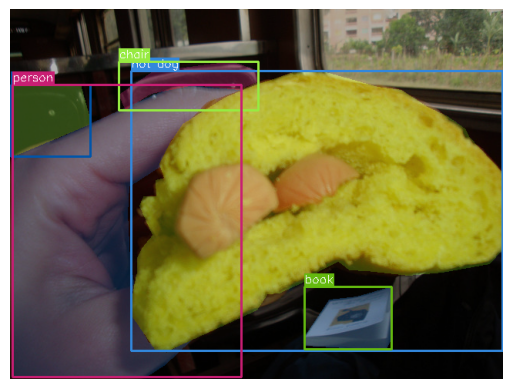

In [37]:
clip_processor = ClipProcessor("cpu")
image, annotations = dataset[0]
annotations_filtered = clip_processor.process_image(image, annotations)

image_vis = dataset.make_visualization(image, annotations_filtered)

plt.imshow(image_vis)
plt.axis('off')
plt.show()

Отфильтруйте предсказания из предыдущего шага, загрузите csv в LMS.

In [68]:
# Initialize the dictionary with empty lists for all required keys
test_annotations = defaultdict(dict)

# Read the CSV file using csv library
with open('test_detections.csv', 'r') as file:
    reader = csv.DictReader(file)
    
    for row in reader:
        # The format is "[[x, y, h, w], ...]"
        bbox = ast.literal_eval(row['bbox'])
        if test_annotations[row['image_id']].get('boxes', None) is None:
            test_annotations[row['image_id']]['boxes'] = []
        test_annotations[row['image_id']]['boxes'].append(bbox)
        
        # Parse labels
        label = row['label']
        if test_annotations[row['image_id']].get('labels', None) is None:
            test_annotations[row['image_id']]['labels'] = []
        test_annotations[row['image_id']]['labels'].append(label)

In [51]:
clip_processor = ClipProcessor("cpu")
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_detections = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    image_id = annotations['image_id']
    annotations = clip_processor.process_image(image, test_annotations[image_id], iou_threshold=0.7)
    for bbox, label in zip(annotations['boxes'], annotations['labels']):
        test_detections.append((image_id, bbox, label))

with open('test_detections_filtered.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'bbox', 'label'])
    writer.writerows(test_detections)

5it [00:04,  1.02it/s]


### Задание 6: Сегментация с помощью SAM

В этой задаче вам необходимо реализовать класс `SamProcessor`, который будет использовать модель SAM (Segment Anything Model) из библиотеки `segment_anything` для генерации сегментационных масок. Скачайте веса по [ссылке](https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth) из [официального репозитория](https://github.com/facebookresearch/segment-anything), возьмите "sam_vit_h_4b8939.pth" и поместите в папку 'pretrained'.

Создайте класс `SamProcessor`, который должен:
   - Инициализировать модель SAM из библиотеки `segment_anything`
   - Иметь метод `process_image`, который принимает:
     - Изображение (numpy массив в формате RGB с диапазоном значений 0-255)
     - Словарь аннотаций, содержащий ключ 'boxes' в формате xyhw (x, y, высота, ширина)
   - Метод `process_image` должен возвращать словарь аннотаций с добавленными ключами 'polygons' и 'masks', где под первым ключом хранятся сегментационные маски в формате полигонов (в 1D после flatten), а под вторым - в качестве бинарных масок.

In [10]:
def mask_to_polygon(mask: np.ndarray, eps: float = 5e-3) -> list[int]:
    mask = mask.astype(np.uint8)
    
    contours, _ = cv2.findContours(
        mask, 
        cv2.RETR_EXTERNAL, 
        cv2.CHAIN_APPROX_SIMPLE
    )
    
    polygons = []
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        
        epsilon = eps * perimeter
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        polygon = approx.reshape(-1, 2)
        polygons.append(polygon)
    
    return polygons

In [11]:
class SamProcessor:
    def __init__(self, device: str = "cpu"):
        pass

    def process_image(self, image: np.ndarray, annotations: dict) -> dict:
        ...
        
        return annotations

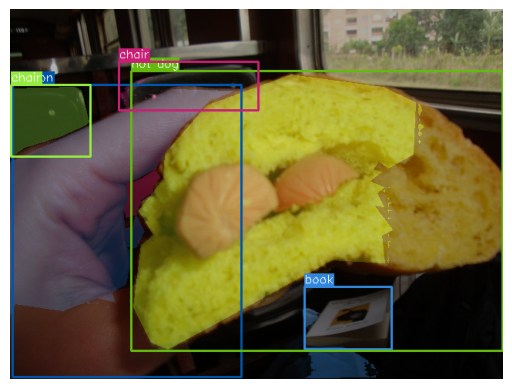

In [ ]:
sam_processor = SamProcessor("cpu")
image, annotations = dataset[0]
annotations = sam_processor.process_image(image, annotations)
annotations['masks'] = [dataset._polygon_to_mask(polygons, *image.shape[:2]) for polygons in annotations['polygons']]
image_vis = dataset.make_visualization(image, annotations)

plt.imshow(image_vis)
plt.axis('off')
plt.show()

Прогоните его по тестовым данным, загрузите csv с парами image_id, mask, label на каждой строке в LMS. Маску сохраняйте как полигоны.

In [63]:
test_annotations = defaultdict(dict)
with open('test_detections_filtered.csv', 'r') as file:
    reader = csv.DictReader(file)
    for row in reader:
        bbox = ast.literal_eval(row['bbox'])
        if test_annotations[row['image_id']].get('boxes', None) is None:
            test_annotations[row['image_id']]['boxes'] = []
        test_annotations[row['image_id']]['boxes'].append(bbox)
        
        label = row['label']
        if test_annotations[row['image_id']].get('labels', None) is None:
            test_annotations[row['image_id']]['labels'] = []
        test_annotations[row['image_id']]['labels'].append(label)

In [64]:
sam_processor = SamProcessor("cpu")
test_dataset = COCODataset(image_dir=test_dir,
                           category_mapping_file=category_mapping_file,
                           annotation_file=None)

test_masks = []
for sample in tqdm(test_dataset):
    image, annotations = sample
    image_id = annotations['image_id']

    annotations['boxes'] = test_annotations[image_id]['boxes']
    annotations['labels'] = test_annotations[image_id]['labels']

    annotations = sam_processor.process_image(image, annotations)
    for polygons, label in zip(annotations['polygons'], annotations['labels']):
        test_masks.append((image_id, polygons, label))

with open('test_masks.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['image_id', 'mask', 'label'])
    for image_id, polygons, label in test_masks:
        writer.writerow([image_id, polygons, label])

5it [01:26, 17.23s/it]


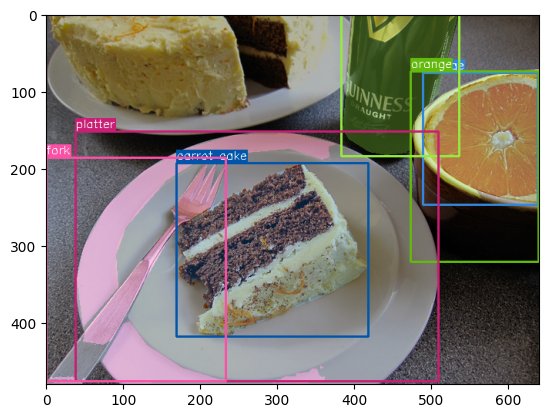

In [67]:
image, annotations = test_dataset[4]
image_id = annotations['image_id']
annotations = test_annotations[image_id]
annotations['masks'] = [test_dataset._polygon_to_mask(polygons, *image.shape[:2]) for id, polygons, _ in test_masks if image_id == id]
image_vis = test_dataset.make_visualization(image, annotations)
plt.imshow(image_vis)